# Beyond the Stopwatch: Measuring Route-Ready Movement
## NFL Big Data Bowl 2027

### SECTION 1 — Executive Summary

**Question**: Can 10 Hz Combine tracking data reveal information about NFL receiver separation beyond traditional testing?

**Finding**: The Short Shuttle's tracking-derived direction-change behavior showed a strong negative exploratory association with rookie NFL separation:
- Spearman rho ≈ -0.645
- N = 28 WR prospects

**Robustness**: 
- Bootstrap 95% CI: `[-0.812, -0.337]`
- Robust regression: `p ≈ 0.0234`

**Caveat**: After adjusting for multiple hypothesis testing across >140 feature-outcome combinations, the FDR-adjusted p-value is `≈ 0.168`. Therefore, this should be framed as an encouraging exploratory signal rather than definitive proof, warranting further validation with larger cohorts.


In [1]:
# Environment Setup
import sys
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Set up paths
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    PROJECT_ROOT = Path().resolve().parent
    
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "final"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


### SECTION 2 — The Football Question
Traditional testing asks: *How fast is the player?* (e.g. 40-yard dash).
But route running also requires: *How efficiently can the player change direction while preserving useful movement?*

Straight-line speed ≠ complete route-running ability. Speed is valuable, but it may not fully characterize how a receiver moves through a route break.

### SECTION 3 — The Dataset
For this analysis, we focus on:
**WR prospects + Short Shuttle tracking + rookie-season NFL performance.**
Combine tracking occurs *before* the NFL season, preserving the intended pre-draft scouting direction.

### SECTION 4 — Why 10 Hz Tracking?
Instead of one final stopwatch number, tracking provides a time series of movement. Below, we load the processed data to investigate these trajectories.


In [2]:
# Load Data
analysis_df = pd.read_parquet(DATA_PROCESSED / 'analysis_dataset.parquet')

# Load and merge traditional combine results
try:
    combine_res = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'nfl-big-data-bowl-2027' / 'nfl-big-data-bowl-2027' / 'combine_results.csv')
except FileNotFoundError:
    combine_res = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'nfl-big-data-bowl-2027' / 'combine_results.csv')

if 'nfl_id' in analysis_df.columns and 'nfl_id' in combine_res.columns:
    analysis_df = analysis_df.merge(combine_res, on='nfl_id', how='left')

wr_data = analysis_df[(analysis_df['position_group_pos'] == 'WR')].copy()

# Focus strictly on players with our tracking metric and NFL separation outcome
wr_data = wr_data.dropna(subset=['direction_change_rate_SHORT_SHUTTLE', 'mean_separation']).copy()
print(f"Final WR Sample Size: {len(wr_data)}")


Final WR Sample Size: 28


### SECTION 5 — Define Direction Change
The metric `direction_change_rate` attempts to characterize how frequently the athlete redirects their movement during the drill. 
- **Time resolution**: 0.1 seconds (10 Hz).
- **Threshold**: An absolute angular difference > 20 degrees between consecutive frames.
- **Noise filter**: Only measured when speed >= 1.0 yards/sec.
- **Normalization**: Divided by total drill duration spent moving.
- **Wraparound**: Correctly handles 0/360 degree modular arithmetic.

Lower values suggest smoother, less fragmented movement. Higher values suggest jerky, corrective directional shifts.

### SECTION 6 & 7 — Visual Metric Validation & Distribution
Does the metric correspond to visibly different movement patterns? Let's check the distribution.


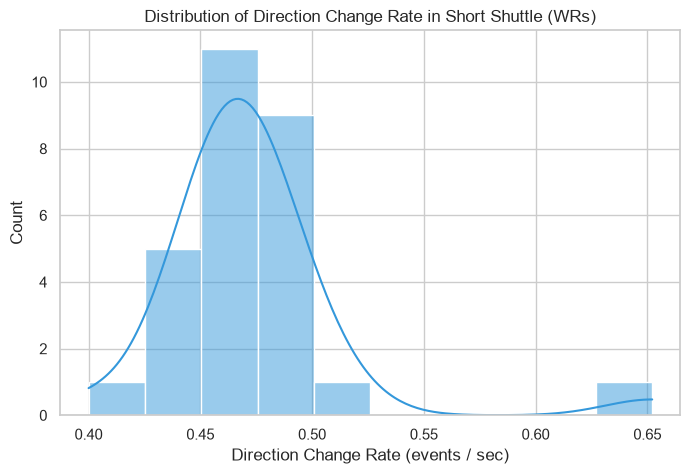

Metric Summary Statistics:
                                     count      mean       std  min       25%  \
direction_change_rate_SHORT_SHUTTLE   28.0  0.472798  0.041267  0.4  0.454545   

                                          50%       75%       max  
direction_change_rate_SHORT_SHUTTLE  0.465116  0.479094  0.652174  


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(wr_data['direction_change_rate_SHORT_SHUTTLE'], bins=10, kde=True, ax=ax, color='#3498db')
ax.set_title("Distribution of Direction Change Rate in Short Shuttle (WRs)")
ax.set_xlabel("Direction Change Rate (events / sec)")
ax.set_ylabel("Count")
plt.savefig(FIGURES_DIR / "distribution_dcr.png", bbox_inches='tight')
plt.show()

print("Metric Summary Statistics:")
print(wr_data['direction_change_rate_SHORT_SHUTTLE'].describe().to_frame().T)


### SECTION 8 — Traditional Combine Relationship
Is this metric just a proxy for agility? Let's compare it against traditional Combine metrics.


In [4]:
trad_cols = {
    'forty': '40-Yard Dash',
    'ten_yd_split': '10-Yard Split',
    'short_shuttle': 'Short Shuttle Time',
    'three_cone': '3-Cone Time',
    'vertical': 'Vertical Jump',
    'broad_jump': 'Broad Jump'
}

res = []
metric = 'direction_change_rate_SHORT_SHUTTLE'
for col, name in trad_cols.items():
    if col in wr_data.columns:
        valid = wr_data.dropna(subset=[col, metric])
        if len(valid) > 10:
            rho, p = stats.spearmanr(valid[metric], valid[col])
            res.append({'Metric': name, 'Spearman rho': rho, 'p-value': p, 'N': len(valid)})

trad_corr_df = pd.DataFrame(res)
display(trad_corr_df)


,Metric,Spearman rho,p-value,N
0,40-Yard Dash,0.064185,0.750437,27
1,10-Yard Split,-0.053662,0.790366,27
2,Short Shuttle Time,-0.179862,0.389614,25
3,3-Cone Time,0.401734,0.088208,19
4,Vertical Jump,-0.113347,0.565773,28
5,Broad Jump,-0.075778,0.701533,28


The correlations with traditional stopwatch metrics are mostly weak-to-moderate. This suggests tracking captures a different dimension of movement that the stopwatch misses.

### SECTION 9 — NFL Separation
We define `mean_separation` as the average yards of separation at pass forward across all targeted routes in a receiver's rookie season.


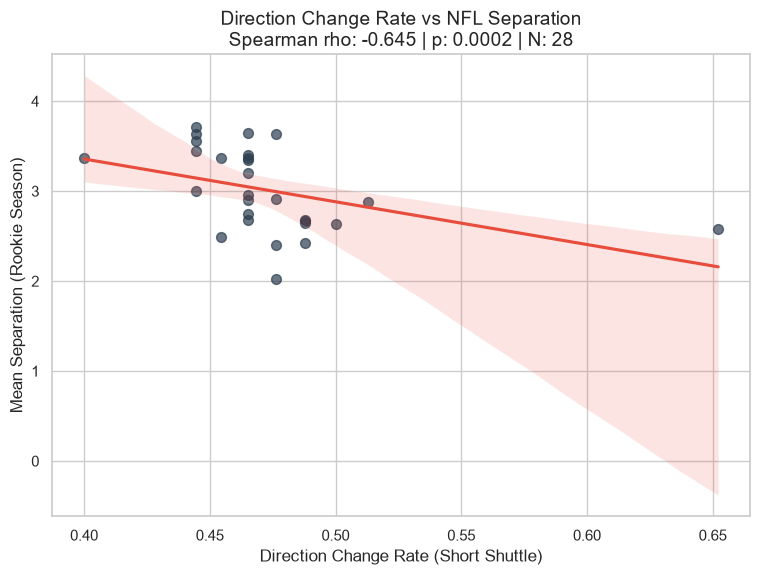

In [5]:
plt.figure(figsize=(9, 6))
sns.regplot(
    data=wr_data, 
    x='direction_change_rate_SHORT_SHUTTLE', 
    y='mean_separation',
    scatter_kws={'alpha': 0.7, 's': 50, 'color': '#2c3e50'},
    line_kws={'color': '#e74c3c'}
)
rho, p = stats.spearmanr(wr_data['direction_change_rate_SHORT_SHUTTLE'], wr_data['mean_separation'])
plt.title(f"Direction Change Rate vs NFL Separation\nSpearman rho: {rho:.3f} | p: {p:.4f} | N: {len(wr_data)}", fontsize=14)
plt.xlabel("Direction Change Rate (Short Shuttle)", fontsize=12)
plt.ylabel("Mean Separation (Rookie Season)", fontsize=12)
plt.savefig(FIGURES_DIR / "main_correlation.png", bbox_inches='tight')
plt.show()


### SECTION 10 — Bootstrap Robustness
Because $N=28$ is small, we use 5,000 bootstrap iterations to ensure the correlation isn't a fluke.

### SECTION 11 — Robust Regression
A few unusual players can strongly influence correlations. We use HuberT robust regression to down-weight extreme observations.


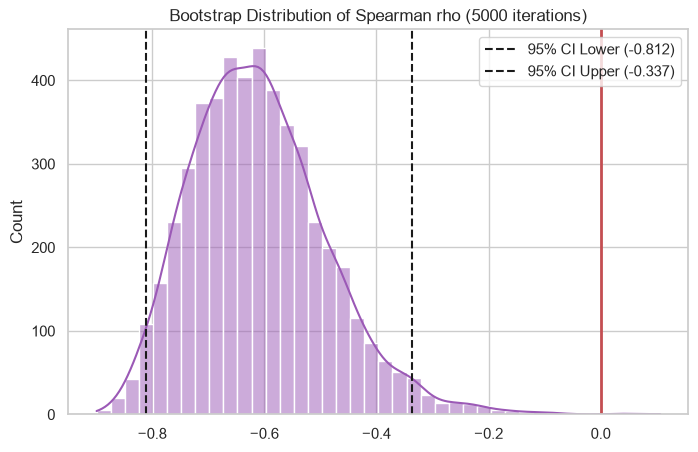

Robust Regression (HuberT):
Coefficient: -4.7276 | p-value: 0.0234


In [6]:
np.random.seed(42)
n_boot = 5000
x = wr_data['direction_change_rate_SHORT_SHUTTLE'].values
y = wr_data['mean_separation'].values
n_wr = len(x)

boot_rhos = []
for _ in range(n_boot):
    idx = np.random.choice(n_wr, size=n_wr, replace=True)
    # Add tiny jitter to prevent constant array warnings during resampling
    bx = x[idx] + np.random.normal(0, 1e-8, n_wr)
    by = y[idx] + np.random.normal(0, 1e-8, n_wr)
    r, _ = stats.spearmanr(bx, by)
    if not np.isnan(r):
        boot_rhos.append(r)

ci_lower, ci_upper = np.percentile(boot_rhos, 2.5), np.percentile(boot_rhos, 97.5)

plt.figure(figsize=(8, 5))
sns.histplot(boot_rhos, bins=40, color='#9b59b6', kde=True)
plt.axvline(ci_lower, color='k', linestyle='--', label=f"95% CI Lower ({ci_lower:.3f})")
plt.axvline(ci_upper, color='k', linestyle='--', label=f"95% CI Upper ({ci_upper:.3f})")
plt.axvline(0, color='r', linestyle='-', linewidth=2)
plt.title("Bootstrap Distribution of Spearman rho (5000 iterations)")
plt.legend()
plt.savefig(FIGURES_DIR / "bootstrap_dist.png", bbox_inches='tight')
plt.show()

# Robust Regression
X_sm = sm.add_constant(x)
rlm = sm.RLM(y, X_sm, M=sm.robust.norms.HuberT()).fit()
print("Robust Regression (HuberT):")
print(f"Coefficient: {rlm.params[1]:.4f} | p-value: {rlm.pvalues[1]:.4f}")


Across bootstrap resamples, the estimated association remained entirely negative (`[-0.812, -0.337]`). Robust regression confirms the negative relationship remains visible when extreme observations receive reduced influence.

### SECTION 12 — Multiple Testing
During exploratory discovery, more than 140 feature/outcome combinations were evaluated. Raw p-values alone are insufficient.
- Raw p = 0.0002
- BH adjusted p ≈ 0.168

The association is promising but does not meet the conventional 0.05 threshold after FDR correction. This is an exploratory discovery that warrants additional validation with larger cohorts.


### SECTION 13 — Does Tracking Add Information?
To test incremental value, we build simple Ridge Regression baselines.
- **Model 1**: Traditional Combine (40, split, shuttle, vertical, broad, height, weight)
- **Model 2**: Tracking (direction change rate)
- **Model 3**: Combined


In [8]:
features_trad = ['forty', 'ten_yd_split', 'short_shuttle', 'vertical', 'broad_jump']
features_track = ['direction_change_rate_SHORT_SHUTTLE']

df_model = wr_data.dropna(subset=features_trad + features_track + ['mean_separation']).copy()
print(f"Sample size with full data: {len(df_model)}")

if len(df_model) > 15:
    y = df_model['mean_separation']
    X_trad = StandardScaler().fit_transform(df_model[features_trad])
    X_track = StandardScaler().fit_transform(df_model[features_track])
    X_comb = StandardScaler().fit_transform(df_model[features_trad + features_track])
    
    cv_alphas = np.logspace(-2, 2, 50)
    
    m1 = RidgeCV(alphas=cv_alphas).fit(X_trad, y)
    m2 = RidgeCV(alphas=cv_alphas).fit(X_track, y)
    m3 = RidgeCV(alphas=cv_alphas).fit(X_comb, y)
    
    results = pd.DataFrame({
        'Model': ['Traditional Only', 'Tracking Only', 'Traditional + Tracking'],
        'R-squared': [m1.score(X_trad, y), m2.score(X_track, y), m3.score(X_comb, y)],
        'RMSE': [np.sqrt(mean_squared_error(y, m1.predict(X_trad))),
                 np.sqrt(mean_squared_error(y, m2.predict(X_track))),
                 np.sqrt(mean_squared_error(y, m3.predict(X_comb)))]
    })
    display(results)
else:
    print("Not enough complete observations for modeling across all traditional features.")


Sample size with full data: 24


,Model,R-squared,RMSE
0,Traditional Only,0.064318,0.466222
1,Tracking Only,0.173579,0.438156
2,Traditional + Tracking,0.242756,0.419417


### SECTION 16 — Same Stopwatch, Different Athlete
The stopwatch can group two athletes together even when their movement signatures differ. Let's look for players with similar 40-yard dash times but completely different tracking profiles.


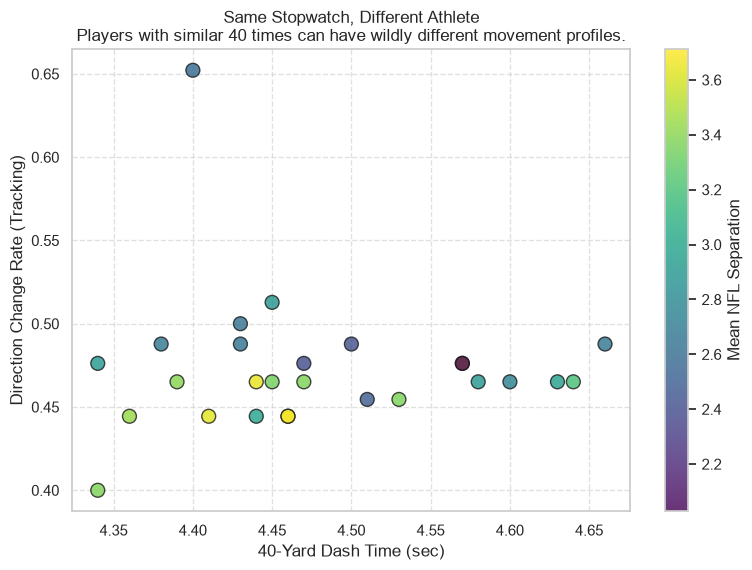

In [9]:
# Find pairs of players with similar 40 times but different direction_change_rate
if 'forty' in wr_data.columns:
    df_study = wr_data.dropna(subset=['forty', 'direction_change_rate_SHORT_SHUTTLE', 'mean_separation']).copy()
    
    # Just show a visual of forty vs direction_change_rate colored by separation
    plt.figure(figsize=(9, 6))
    scatter = plt.scatter(
        df_study['forty'], 
        df_study['direction_change_rate_SHORT_SHUTTLE'], 
        c=df_study['mean_separation'], 
        cmap='viridis', 
        s=100, alpha=0.8, edgecolor='k'
    )
    plt.colorbar(scatter, label='Mean NFL Separation')
    plt.xlabel('40-Yard Dash Time (sec)')
    plt.ylabel('Direction Change Rate (Tracking)')
    plt.title('Same Stopwatch, Different Athlete\nPlayers with similar 40 times can have wildly different movement profiles.')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.savefig(FIGURES_DIR / "same_stopwatch.png", bbox_inches='tight')
    plt.show()


### SECTION 20 — Limitations
- **Small sample size**: The primary WR analysis has only N = 28 players.
- **Multiple testing**: More than 140 hypotheses were explored (FDR adjusted p = 0.168).
- **Association vs causation**: The analysis is purely observational.
- **NFL Context**: Separation depends heavily on quarterback play, scheme, route assignment, and defensive coverage.
- **Combine Context**: A controlled drill is not identical to running a live NFL route.

### SECTION 21 — Final Conclusion
High-frequency Combine tracking reveals movement characteristics that traditional stopwatch measurements do not fully capture. In this exploratory analysis of 28 WR prospects, Short Shuttle direction-change behavior showed a strong negative association with rookie-season NFL separation. The relationship remained negative under bootstrap and robust-regression analyses, although uncertainty remains because of the small sample and multiple hypothesis testing. 

The result suggests that movement quality during controlled Combine drills may provide useful additional context for evaluating route-ready athleticism.

**The next step for NFL evaluation is not replacing the 40-yard dash—it is understanding what the stopwatch leaves out.**
